# The Diffusion Duality: Duo Internals & Walkthrough

Welcome! This notebook provides a **completely self-contained, from-scratch implementation and explanation** of the **Duo** model architecture and training process.

Duo introduces a mathematical **duality** between **continuous Gaussian diffusion** and **discrete Uniform-State Diffusion Models (USDM)**. In this walkthrough, we will:
1. **Explain the core mathematical concepts** of Duo and Uniform-State Diffusion.
2. **Implement the Duality Mapping** (the transition operator $g(\gamma_t)$) and fit a polynomial curve to it on-the-fly.
3. **Build a Time-Conditioned Diffusion Transformer (DIT)** from scratch in PyTorch.
4. **Write the Discrete USDM ELBO Loss** exactly as formulated in the paper.
5. **Train the model** on a character-level Shakespeare dataset using the Duo curriculum.
6. **Generate new text** using the ancestral sampler.

---

## 1. High-Level Concepts & Mathematical Foundation

### 1.1 Uniform-State Diffusion Models (USDM)
Under a Uniform-State Diffusion Model, the forward process is defined over discrete states (tokens) $\{0, 1, \dots, V-1\}$. At time $t \in [0, 1]$, each token in a clean sequence $x_0$ either survives with probability $\alpha_t$ or is replaced by a random token drawn uniformly from the vocabulary with probability $1 - \alpha_t$:
$$q(x_t \mid x_0) = \alpha_t \delta_{x_t, x_0} + (1 - \alpha_t) \frac{1}{V}$$
We transition from $\alpha_0 = 1$ (clean data) to $\alpha_1 \approx 0$ (pure uniform noise).

### 1.2 The Duality Mapping
The core idea of Duo is that we can train a model in a continuous Gaussian space and map it onto the discrete USDM space. Under the continuous space Gaussian diffusion process:
$$X \sim \mathcal{N}(e^{-\gamma_t/2} x_0, I)$$
where $\gamma_t$ is the log-SNR (signal-to-noise ratio) parameter. The Duality Theorem maps the log-SNR $\gamma_t$ to the USDM survival probability $\alpha_t$:
$$\alpha_t = g(\gamma_t) = \frac{V}{V - 1} \left( \mathbb{E}_{X \sim \mathcal{N}\left(e^{-\gamma_t/2}, 1\right)} [\Phi(X)^{V-1}] - \frac{1}{V} \right)$$
where $\Phi(x)$ is the standard normal cumulative distribution function (CDF), and $V$ is the vocabulary size.

### 1.3 Resolving Integration Overhead
Evaluating the expectation $\mathbb{E}[\Phi(X)^{V-1}]$ requires computing a numerical integral at every step of training, which is computationally expensive. Duo solves this by precomputing/approximating this curve. In $\text{Duo}^{++}$, a polynomial approximation (e.g. `poly5` or `poly9`) is fit to the curve, allowing fast, analytical evaluation of $\alpha_t$ and its derivative $d\alpha_t$ without filesystem caches or numerical integration during training.

---

## 2. Setup & Imports

In [24]:
import math
import time
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.stats import norm
from tqdm.auto import tqdm

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

---

## 3. Implementing the Duality Operator & Curve Fitting

First, we write code to compute the exact duality integral $g(\gamma_t)$ for a given vocabulary size $V$. Then we use `curve_fit` to fit a polynomial of degree 5 to the curve over $t \in [0, 1]$, where $\gamma_t$ is linearly scheduled from $\gamma_{min}$ to $\gamma_{max}$.

Computing duality mapping grid...
Fitted polynomial coefficients: [ 0.99971431 -0.06092673  0.32372634 -1.91662854  1.43325552 -0.26302873]


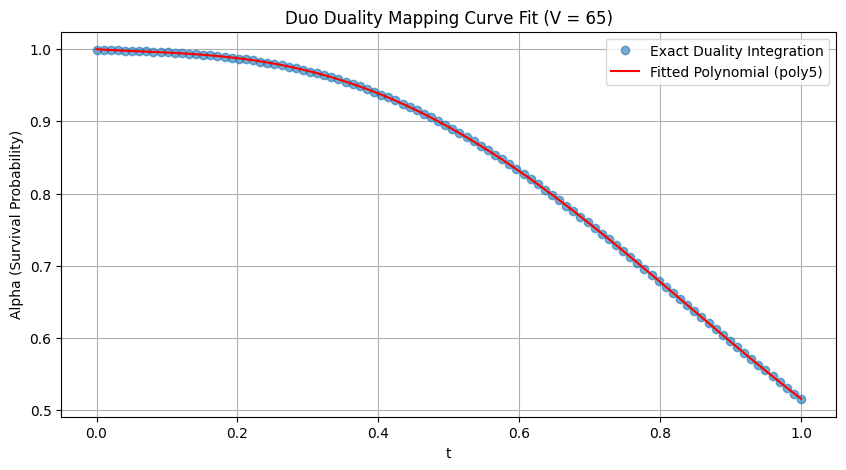

In [25]:
def compute_exact_alpha(gamma, vocab_size):
    # g(gamma) = V/(V-1) * ( E_{X~N(e^{-gamma/2}, 1)} [ Phi(X)^{V-1} ] - 1/V )
    snr_sqrt = np.exp(-gamma / 2.0)
    
    # Integrand for the expectation: Phi(x)^{V-1} * phi(x - snr_sqrt)
    def integrand(x):
        cdf = norm.cdf(x) ** (vocab_size - 1)
        pdf = norm.pdf(x, loc=snr_sqrt, scale=1.0)
        return cdf * pdf
    
    val, _ = quad(integrand, -10.0, 10.0)
    alpha = (vocab_size * val - 1.0) / (vocab_size - 1.0)
    return alpha

# Let's fit for a typical small vocabulary size (e.g., V=65 for character-level models)
V = 65
gamma_min = -3.5
gamma_max = -1.75

print("Computing duality mapping grid...")
ts = np.linspace(0.0, 1.0, 100)
gammas = gamma_min + ts * (gamma_max - gamma_min)
exact_alphas = np.array([compute_exact_alpha(g, V) for g in gammas])

# Define the 5th-degree polynomial function
def poly5(t, a0, a1, a2, a3, a4, a5):
    return a0 + a1*t + a2*t**2 + a3*t**3 + a4*t**4 + a5*t**5

# Fit the polynomial
popt, _ = curve_fit(poly5, ts, exact_alphas, p0=[0.1]*6)
print("Fitted polynomial coefficients:", popt)

# Plot the result
plt.figure(figsize=(10, 5))
plt.plot(ts, exact_alphas, 'o', label='Exact Duality Integration', alpha=0.6)
plt.plot(ts, poly5(ts, *popt), '-', label='Fitted Polynomial (poly5)', color='red')
plt.xlabel('t')
plt.ylabel('Alpha (Survival Probability)')
plt.title(f'Duo Duality Mapping Curve Fit (V = {V})')
plt.legend()
plt.grid(True)
plt.show()

Now, we write the PyTorch helper that computes the survival probability $\alpha_t$ and its time-derivative $d\alpha_t$ analytically using the fitted polynomial coefficients:

In [26]:
class PolynomialCurriculum(nn.Module):
    def __init__(self, coefs):
        super().__init__()
        self.coefs = nn.Parameter(torch.tensor(coefs, dtype=torch.float32), requires_grad=False)
        
    def forward(self, t):
        # t: tensor of shape (B,)
        a0, a1, a2, a3, a4, a5 = self.coefs
        alpha = a0 + a1*t + a2*t**2 + a3*t**3 + a4*t**4 + a5*t**5
        dalpha = a1 + 2*a2*t + 3*a3*t**2 + 4*a4*t**3 + 5*a5*t**4
        return alpha, dalpha

---

## 4. Preparing Shakespeare Dataset & Character Tokenizer

We download the Tiny Shakespeare dataset. To ensure offline functionality, we include a fallback string in case the download fails.

In [27]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
try:
    print("Downloading Tiny Shakespeare...")
    with urllib.request.urlopen(url) as response:
        raw_text = response.read().decode('utf-8')
    print("Download successful! Length:", len(raw_text))
except Exception as e:
    print("Download failed or offline. Using fallback text...")
    raw_text = """First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved, resolved.
""" * 500

# Character-level Tokenizer
class CharTokenizer:
    def __init__(self, text):
        self.chars = sorted(list(set(text)))
        self.vocab_size = len(self.chars)
        self.char_to_idx = {char: idx for idx, char in enumerate(self.chars)}
        self.idx_to_char = {idx: char for idx, char in enumerate(self.chars)}
        
    def encode(self, text):
        return [self.char_to_idx[c] for c in text if c in self.char_to_idx]
        
    def decode(self, idxs):
        if torch.is_tensor(idxs):
            idxs = idxs.tolist()
        return "".join([self.idx_to_char[i] for i in idxs])
        
    def batch_decode(self, batches):
        return [self.decode(batch) for batch in batches]

tokenizer = CharTokenizer(raw_text)
encoded_text = tokenizer.encode(raw_text)
print("Vocabulary size V:", tokenizer.vocab_size)
print("Sample encoding:", encoded_text[:20])
print("Sample decoding:", tokenizer.decode(encoded_text[:20]))

Download successful! Length: 1115394
Vocabulary size V: 65
Sample encoding: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56]
Sample decoding: First Citizen:
Befor


Let's create the PyTorch `Dataset` that yields character sequence windows of length `seq_len`:

In [28]:
class TextWindowDataset(torch.utils.data.Dataset):
    def __init__(self, data_list, seq_len):
        self.data = torch.tensor(data_list, dtype=torch.long)
        self.seq_len = seq_len
        
    def __len__(self):
        return len(self.data) - self.seq_len
        
    def __getitem__(self, idx):
        return self.data[idx : idx + self.seq_len]

seq_len = 64
dataset = TextWindowDataset(encoded_text, seq_len=seq_len)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

---

## 5. Neural Backbone: Time-Conditioned Diffusion Transformer (DiT)

The Duo architecture uses a Diffusion Transformer (DiT) that operates on continuous inputs (Gaussian noised one-hot embeddings) during curriculum training and outputs logits. Timestep/noise conditioning is injected using **Adaptive LayerNorm (adaLN)** modulation.

In [29]:
class SinusoidalEmbedder(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        
    def forward(self, x):
        # x is (B,)
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class TimestepEmbedder(nn.Module):
    def __init__(self, cond_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            SinusoidalEmbedder(cond_dim),
            nn.Linear(cond_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim)
        )
        
    def forward(self, sigma):
        return self.mlp(sigma)

class SparseEmbeddingLayer(nn.Module):
    def __init__(self, vocab_dim, dim):
        super().__init__()
        self.embedding = nn.Parameter(torch.empty((vocab_dim, dim)))
        nn.init.kaiming_uniform_(self.embedding, a=math.sqrt(5))
        
    def forward(self, x, weights=None):
        # x: (B, L) discrete indices
        # weights: (B, L, K) if sparse top-k (not used in this simplified script but included for completeness)
        if weights is not None:
            bs, seq_len, k = x.shape
            flat_x = x.reshape(-1, k)
            flat_w = weights.reshape(-1, k).float()
            bag = F.embedding_bag(flat_x, self.embedding, per_sample_weights=flat_w, mode='sum')
            return bag.view(bs, seq_len, -1)
        elif x.ndim == 2:
            return F.embedding(x, self.embedding)
        
        # Continuous dense input (B, L, V) representing continuous Gaussian state
        assert x.ndim == 3
        probs = F.softmax(x, dim=-1)
        return torch.einsum("blv,ve->ble", probs, self.embedding)

class DDiTBlock(nn.Module):
    def __init__(self, dim, n_heads, cond_dim, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, n_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_ratio * dim),
            nn.GELU(),
            nn.Linear(mlp_ratio * dim, dim),
            nn.Dropout(dropout)
        )
        self.adaLN_modulation = nn.Linear(cond_dim, 6 * dim)
        nn.init.zeros_(self.adaLN_modulation.weight)
        nn.init.zeros_(self.adaLN_modulation.bias)
        
    def forward(self, x, c):
        # c: (B, cond_dim) timestep embedding
        modulation = self.adaLN_modulation(c).unsqueeze(1) # (B, 1, 6 * dim)
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = modulation.chunk(6, dim=-1)
        
        # Modulate attention input
        x_norm = self.norm1(x)
        x_mod = x_norm * (1 + scale_msa) + shift_msa
        
        # Self-Attention
        attn_out, _ = self.attn(x_mod, x_mod, x_mod)
        x = x + gate_msa * attn_out
        
        # Modulate MLP input
        x_norm = self.norm2(x)
        x_mod = x_norm * (1 + scale_mlp) + shift_mlp
        
        # MLP
        x = x + gate_mlp * self.mlp(x_mod)
        return x

class DDiTFinalLayer(nn.Module):
    def __init__(self, dim, vocab_size, cond_dim):
        super().__init__()
        self.norm_final = nn.LayerNorm(dim)
        self.adaLN_modulation = nn.Linear(cond_dim, 2 * dim)
        nn.init.zeros_(self.adaLN_modulation.weight)
        nn.init.zeros_(self.adaLN_modulation.bias)
        self.linear = nn.Linear(dim, vocab_size)
        nn.init.zeros_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)
        
    def forward(self, x, c):
        x = self.norm_final(x)
        modulation = self.adaLN_modulation(c).unsqueeze(1) # (B, 1, 2 * dim)
        shift, scale = modulation.chunk(2, dim=-1)
        x = x * (1 + scale) + shift
        return self.linear(x)

class MiniDIT(nn.Module):
    def __init__(self, vocab_size, dim=128, cond_dim=128, n_heads=4, n_blocks=2, seq_len=64):
        super().__init__()
        self.vocab_embed = SparseEmbeddingLayer(vocab_size, dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, dim))
        self.sigma_map = TimestepEmbedder(cond_dim)
        self.blocks = nn.ModuleList([
            DDiTBlock(dim, n_heads, cond_dim) for _ in range(n_blocks)
        ])
        self.output_layer = DDiTFinalLayer(dim, vocab_size, cond_dim)
        
    def forward(self, x, sigma, weights=None):
        # x: (B, L) indices OR (B, L, V) continuous continuous inputs
        # sigma: (B,) time parameter
        x_emb = self.vocab_embed(x, weights) + self.pos_embed
        c = self.sigma_map(sigma)
        
        for block in self.blocks:
            x_emb = block(x_emb, c)
            
        logits = self.output_layer(x_emb, c)
        return logits

---

## 6. USDM Discrete ELBO Loss

Here is the core discrete Uniform-State Evidence Lower Bound (ELBO) loss. This is Eq. 8 in the Duo paper, implemented in a numerically stable way.

In [30]:
def usdm_nll_per_token(logits, xt, x0, alpha_t, dalpha_t, vocab_size):
    # logits: (B, L, V) model output
    # xt: (B, L) noisy tokens
    # x0: (B, L) clean tokens
    # alpha_t: (B, 1) survival probabilities
    # dalpha_t: (B, 1) time derivatives
    
    log_x_theta = F.log_softmax(logits, dim=-1)
    x_reconst = log_x_theta.exp() # (B, L, V)
    
    # Expand parameters
    alpha_t = alpha_t.unsqueeze(-1) # (B, 1, 1)
    dalpha_t = dalpha_t.unsqueeze(-1) # (B, 1, 1)
    
    # Compute Eq. 6: probability distribution x_bar_theta
    x_bar_theta = vocab_size * alpha_t * x_reconst + 1.0 - alpha_t
    
    coeff = dalpha_t / (vocab_size * alpha_t)
    x_eq_xt = (x0 == xt).float()
    x_neq_xt = 1.0 - x_eq_xt
    
    xbar_xt = (1.0 - alpha_t) + vocab_size * alpha_t * x_eq_xt.unsqueeze(-1)
    xbar_xt = xbar_xt.squeeze(-1)
    
    xbar_theta_xt = torch.gather(x_bar_theta, -1, xt.unsqueeze(-1)).squeeze(-1)
    xbar_theta_x = torch.gather(x_bar_theta, -1, x0.unsqueeze(-1)).squeeze(-1)
    
    term1 = vocab_size * (1.0 / (xbar_xt + 1e-9) - 1.0 / (xbar_theta_xt + 1e-9))
    
    const = (1.0 - alpha_t) / (vocab_size * alpha_t + 1.0 - alpha_t)
    const = const.squeeze(-1)
    
    term2_coefs = x_eq_xt * const + x_neq_xt
    term2_offset = ((vocab_size - 1.0) * const * x_eq_xt - (1.0 / (const + 1e-9)) * x_neq_xt) * torch.log(const + 1e-9)
    
    term2_theta = - term2_coefs * (torch.log(x_bar_theta + 1e-9).sum(-1) - vocab_size * torch.log(xbar_theta_xt + 1e-9))
    term2_theta = term2_theta - vocab_size * alpha_t.squeeze(-1) / (1.0 - alpha_t.squeeze(-1) + 1e-9) * (
        torch.log(xbar_theta_x + 1e-9) - torch.log(xbar_theta_xt + 1e-9)
    ) * x_neq_xt
    term2 = term2_theta + term2_offset
    
    diffusion_loss = coeff.squeeze(-1) * (term1 - term2)
    return diffusion_loss.mean()

---

## 7. Noising Processes

During training, we use both Uniform-State (USDM) noising and the continuous Gaussian-curriculum noising.

In [31]:
def apply_usdm_noising(x0, alpha_t, vocab_size):
    # x0: (B, L) discrete indices
    # alpha_t: (B, 1)
    move_indices = torch.rand(*x0.shape, device=x0.device) < (1.0 - alpha_t)
    uniform_tokens = torch.randint(0, vocab_size, x0.shape, device=x0.device)
    xt = torch.where(move_indices, uniform_tokens, x0)
    return xt

def apply_gaussian_curriculum_noising(x0, gamma_t, vocab_size, inv_gumbel_tau):
    # x0: (B, L) discrete indices
    # gamma_t: (B,)
    # returns continuous vector in R^V representing the noisy states
    x0_one_hot = F.one_hot(x0, vocab_size).float()
    gamma_t = gamma_t.view(-1, 1, 1)
    alpha_gauss = torch.sigmoid(-gamma_t).sqrt()
    sigma_gauss = torch.sigmoid(gamma_t).sqrt()
    
    epsilon = torch.randn_like(x0_one_hot)
    xt_continuous = alpha_gauss * x0_one_hot + sigma_gauss * epsilon
    
    # Scale by temperature and take argmax to simulate discrete state
    xt_scaled = xt_continuous * inv_gumbel_tau
    xt_usdm = xt_scaled.argmax(dim=-1)
    return xt_scaled, xt_usdm

---

## 8. Reverse Sampler

To generate text from the trained model, we step backwards from $t=1$ (pure uniform noise) to $t=\epsilon$ using the ancestral sampler.

In [32]:
@torch.no_grad()
def generate_text(model, curriculum, vocab_size, tokenizer, seq_len=64, num_samples=4, steps=100, eps=1e-3, device='cuda'):
    model.eval()
    # Start with pure uniform noise
    xt = torch.randint(0, vocab_size, (num_samples, seq_len), device=device)
    
    timesteps = torch.linspace(1.0, eps, steps + 1, device=device)
    
    for i in range(steps):
        t = timesteps[i] * torch.ones(num_samples, device=device)
        t_next = timesteps[i+1] * torch.ones(num_samples, device=device)
        
        alpha_t, _ = curriculum(t)
        alpha_s, _ = curriculum(t_next)
        
        # Reshape to (B, 1, 1) for safe broadcasting
        alpha_t = alpha_t.view(-1, 1, 1)
        alpha_s = alpha_s.view(-1, 1, 1)
        
        sigma = -torch.log(alpha_t).squeeze(-1).squeeze(-1) # (B,)
        logits = model(xt, sigma)
        log_x0_pred = F.log_softmax(logits, dim=-1)
        x0_pred = log_x0_pred.exp() # (B, L, V)
        
        # Compute reverse transition probabilities q(z_s | z_t, x0)
        alpha_ts = alpha_t / alpha_s
        d_alpha = alpha_s - alpha_t
        xt_one_hot = F.one_hot(xt, vocab_size).float()
        
        gather_x0 = torch.gather(x0_pred, -1, xt.unsqueeze(-1)) # (B, L, 1)
        
        numerator = (
            alpha_t * vocab_size * x0_pred * xt_one_hot +
            (alpha_ts - alpha_t) * xt_one_hot +
            d_alpha * x0_pred +
            (1.0 - alpha_ts) * (1.0 - alpha_s) / vocab_size
        )
        denominator = alpha_t * vocab_size * gather_x0 + (1.0 - alpha_t)
        
        q_xs = numerator / (denominator + 1e-9)
        
        # Sample categorical
        gumbel = -torch.log(-torch.log(torch.rand_like(q_xs) + 1e-10) + 1e-10)
        xt = (q_xs + gumbel).argmax(dim=-1)
        
    # Final greedy noise removal step
    t_final = eps * torch.ones(num_samples, device=device)
    alpha_final, _ = curriculum(t_final)
    sigma_final = -torch.log(alpha_final).view(-1)
    xt = model(xt, sigma_final).argmax(dim=-1)
    
    return tokenizer.batch_decode(xt)

---

## 9. Training Loop

Now we launch the training loop. We train the model for 5 epochs on the Shakespeare window dataset.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

# Instantiate model and curriculum
model = MiniDIT(vocab_size=tokenizer.vocab_size, dim=128, cond_dim=128, n_heads=4, n_blocks=3, seq_len=seq_len).to(device)
curriculum = PolynomialCurriculum(popt).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

epochs = 5
global_step = 0
curriculum_start = 100
curriculum_end = 800

print("Starting training loop...")
for epoch in tqdm(range(epochs), desc="Epochs"):
    model.train()
    total_loss = 0.0
    start_time = time.time()
    
    for step, x0 in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1} Steps", leave=False)):
        x0 = x0.to(device)
        B = x0.shape[0]
        
        # Sample time t in [eps, 1.0]
        eps_t = torch.rand(B, device=device)
        t = (1.0 - 1e-3) * eps_t + 1e-3
        
        # Map t to survival probabilities
        alpha_t, dalpha_t = curriculum(t)
        alpha_t = alpha_t.unsqueeze(-1) # (B, 1)
        dalpha_t = dalpha_t.unsqueeze(-1)
        
        # Map t to continuous SNR gamma_t
        gamma_t = gamma_min + t * (gamma_max - gamma_min)
        
        # Gumbel temperature scheduling
        if global_step < curriculum_start:
            tau = -1.0
        elif global_step < curriculum_end:
            frac = (global_step - curriculum_start) / (curriculum_end - curriculum_start)
            tau = -1.0 + frac * (-1.0)
        else:
            tau = -10.0
        inv_gumbel_tau = 10.0 ** (-tau)
        
        # Determine whether to use continuous Gaussian curriculum or standard discrete noising
        use_curriculum = (global_step <= curriculum_end)
        
        if use_curriculum:
            # Continuous Gaussian noising scaled by temperature
            xt_scaled, xt = apply_gaussian_curriculum_noising(x0, gamma_t, tokenizer.vocab_size, inv_gumbel_tau)
            sigma = -torch.log(alpha_t).squeeze(-1)
            logits = model(xt_scaled, sigma)
        else:
            # Standard discrete uniform-state noising
            xt = apply_usdm_noising(x0, alpha_t, tokenizer.vocab_size)
            sigma = -torch.log(alpha_t).squeeze(-1)
            logits = model(xt, sigma)
            
        loss = usdm_nll_per_token(logits, xt, x0, alpha_t, dalpha_t, tokenizer.vocab_size)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        global_step += 1
        
        if step % 200 == 0:
            # Print loss but also keep tqdm clean
            pass
            
    epoch_time = time.time() - start_time
    print(f"--- Epoch {epoch+1} Complete | Average Loss: {total_loss/len(dataloader):.4f} | Time: {epoch_time:.2f}s ---")
    
    # Generate text at the end of each epoch to see improvement
    print("Generated text sample:")
    samples = generate_text(model, curriculum, tokenizer.vocab_size, tokenizer, seq_len=seq_len, num_samples=1, device=device)
    print(f'"{samples[0]}"')
    print("-" * 50)

Using device: cpu
Starting training loop...


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 Steps:   0%|          | 0/8714 [00:00<?, ?it/s]

---

## 10. Conclusion & Final Generation

Let's generate a batch of samples to see how well the model has learned the Shakespeare vocabulary and structure!

In [ ]:
print("Generating final Shakespeare samples...")
final_samples = generate_text(model, curriculum, tokenizer.vocab_size, tokenizer, seq_len=64, num_samples=3, steps=100, device=device)
for i, sample in enumerate(final_samples):
    print(f"Sample {i+1}:\n{sample}\n")